## Extent

Instead of looking at the upset plots of one checkpoint, lets include the
checkpoint dimension by setting the pass@256 of a question to 1, if any checkpoint
solves it. This would make a statement about the *training-process* instead of the last checkpoint.

In [1]:
outcome_based_plotdir = "/u/rfechner/verl/plots/outcome_based2"

In [2]:
import os
import pickle
import pathlib
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from util import rollouts, qw7_rollouts, model_marker_mapper, method_color_mapper, model_name_mapper, method_name_mapper

In [3]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [4]:
passk = rollouts(recompute=False)
passk_qw = qw7_rollouts(recompute=False)
del passk_qw['qwen2.5_7b__entropy_reg']
passk_keys = [k for k in passk.keys()]
for k in passk_keys:
    if k.endswith('gspo'):
        del passk[k]

models = set([x.split('__')[0] for x in passk.keys()])
methods = set([x.split('__')[1] for x in passk.keys()])

qw_models = set([x.split('__')[0] for x in passk_qw.keys()])
qw_methods = set([x.split('__')[1] for x in passk_qw.keys()])

models, methods

Reading Experiment 13 + selective Qwen2.5-7B rollouts.
Reading Qwen2.5-7B rollouts


({'eurollm_9b_instruct',
  'llama_3.1_8b_instruct',
  'qwen2.5_1.5b',
  'qwen2.5_7b'},
 {'grpo', 'grpo-passk', 'grpo-s', 'kl-cov'})

In [17]:
from typing import Literal
def _filter_uninformative(data_dict: dict):
    if not data_dict: return {}
    stack = np.stack(list(data_dict.values()), axis=0)
    # Entferne Fragen, die bei allen Methoden 0 oder bei allen 1 sind
    keep_mask = ~(np.all(stack, axis=0) | ~np.any(stack, axis=0))
    return {name: mask[keep_mask] for name, mask in data_dict.items()}

def preprocess_extent(subset: dict, pretty_name: Literal['method', 'model']):
    extent = {}
    for method_key, checkpoints in subset.items():
        # Basismodell (Checkpoint '0')
        base_res = np.concatenate(list(checkpoints['0'].values()), axis=0)[:, -1] >= 0.5
        
        # Alle Checkpoints sammeln
        all_res = []
        for cp_id in checkpoints.keys():
            res = np.concatenate(list(checkpoints[cp_id].values()), axis=0)[:, -1] >= 0.5
            all_res.append(res)
        
        # Mindestens einer löst es UND Basis konnte es nicht
        at_least_one_solved = np.any(np.stack(all_res), axis=0)
        new_knowledge = at_least_one_solved & ~base_res
        
        mo, me = method_key.split('__')
        name = method_name_mapper[me] if pretty_name == 'method' else model_name_mapper[mo]
        extent[name] = new_knowledge

    return _filter_uninformative(extent)

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import from_indicators, plot
def plot_upset_extent(extent, title_suffix):
    """
    Erstellt UpSet-Plots für den 'Extent' (Fragen, die von mindestens einem Checkpoint gelöst wurden).
    Farbe: Steelblue (neutraler als Green/Red)
    """
    if not extent:
        return

    # Umwandlung in DataFrame: Zeilen = Fragen, Spalten = Methoden
    df = pd.DataFrame(extent)
    
    # UpSetPlot erwartet Series mit MultiIndex der Indikatoren
    upset_data = from_indicators(indicators=df.columns, data=df)
    
    fig = plt.figure(figsize=(7, 5)) # Etwas breiter für bessere Lesbarkeit
    
    # Plotting
    plot(upset_data, 
         fig=fig, 
         facecolor="#28812FFF", # Steelblue
         sort_by='cardinality', 
         show_counts=True)
    
    title = f"Extent Intersections {title_suffix}"
    fig.suptitle(title, fontsize=12)
    
    # Speichern
    keys = [k.replace('@', '_at_') for k in extent.keys()]
    suffix = title_suffix.strip().replace(' ', '_')
    outfile = f"UpSet__extent__{'-'.join(keys)}__{suffix}.pdf"
    
    save_path = os.path.join(outcome_based_plotdir, outfile)
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    
    plt.show()
    plt.close(fig)

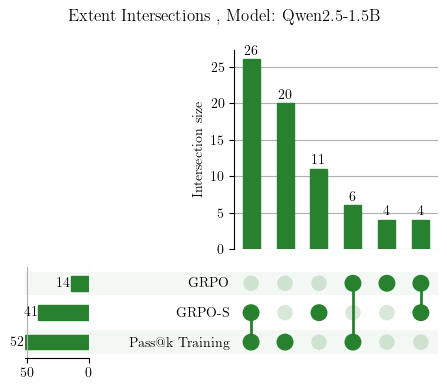

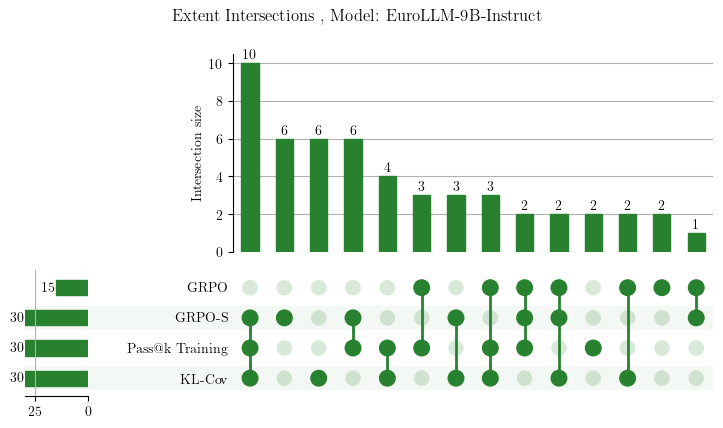

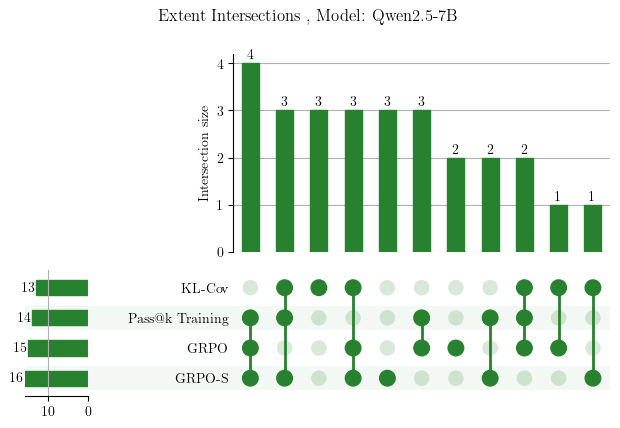

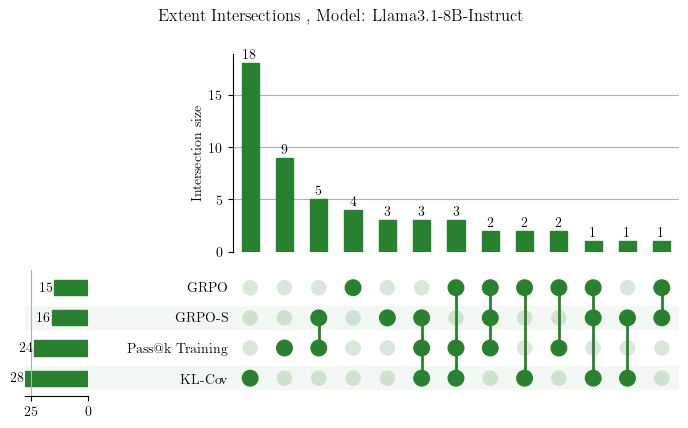

In [28]:
import warnings
warnings.filterwarnings("ignore")
for m in models:
    subset = {k : v for k ,v in passk.items() if m in k}
    extent = preprocess_extent(subset, pretty_name='method')
    title = f", Model: {model_name_mapper[m]}"
    plot_upset_extent(extent, title_suffix=title)

In [29]:
def preprocess_blindspots(subset: dict, pretty_name: Literal['method', 'model']):
    blindspots = {}
    for method_key, checkpoints in subset.items():
        # Basismodell (Checkpoint '0')
        base_res = np.concatenate(list(checkpoints['0'].values()), axis=0)[:, -1] >= 0.5
        
        # Alle Checkpoints sammeln
        all_res = []
        for cp_id in checkpoints.keys():
            res = np.concatenate(list(checkpoints[cp_id].values()), axis=0)[:, -1] >= 0.5
            all_res.append(res)
        
        # Mindestens einer scheitert UND Basis konnte es
        # (np.all(stack) == True bedeutet: alle haben es gelöst)
        at_least_one_failed = ~np.all(np.stack(all_res), axis=0)
        instability = at_least_one_failed & base_res
        
        mo, me = method_key.split('__')
        name = method_name_mapper[me] if pretty_name == 'method' else model_name_mapper[mo]
        blindspots[name] = instability

    return _filter_uninformative(blindspots)

In [30]:
def plot_upset_blindspots(blindspots, title_suffix):
    """
    Erstellt UpSet-Plots für 'Blindspots' (Fragen, die von keinem Checkpoint gelöst wurden).
    Farbe: Muted Purple (#7570B3)
    """
    if not blindspots:
        print("Keine differenzierenden Blindspots gefunden.")
        return

    # DataFrame Erstellung (Fragen als Zeilen, Methoden als Spalten)
    df = pd.DataFrame(blindspots)
    
    # Konvertierung für upsetplot
    upset_data = from_indicators(indicators=df.columns, data=df)
    
    fig = plt.figure(figsize=(7, 5))
    
    # Plotting: Fokus auf die Schnittmengen der 'Versäumnisse'
    plot(upset_data, 
         fig=fig, 
         facecolor="#8F3C3C", 
         sort_by='cardinality', 
         show_counts=True)
    
    title = f"Blindspot Intersections (Solved by 0 Checkpoints) {title_suffix}"
    fig.suptitle(title, fontsize=12)
    
    # Dynamisches Dateinamen-Handling
    keys = [k.replace('@', '_at_') for k in blindspots.keys()]
    suffix = title_suffix.strip().replace(' ', '_')
    outfile = f"UpSet__blindspots__{'-'.join(keys)}__{suffix}.pdf"
    
    save_path = os.path.join(outcome_based_plotdir, outfile)
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    
    plt.show()
    plt.close(fig)

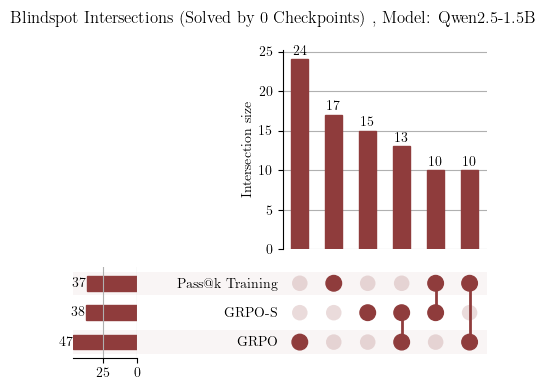

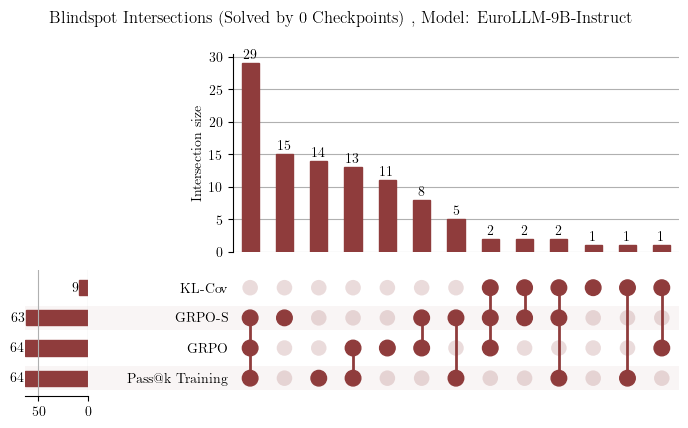

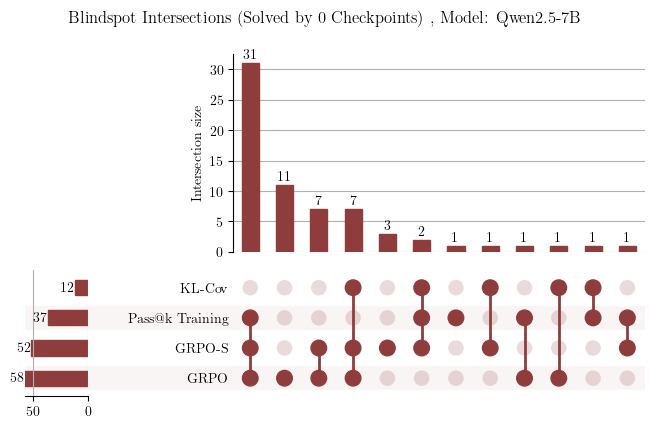

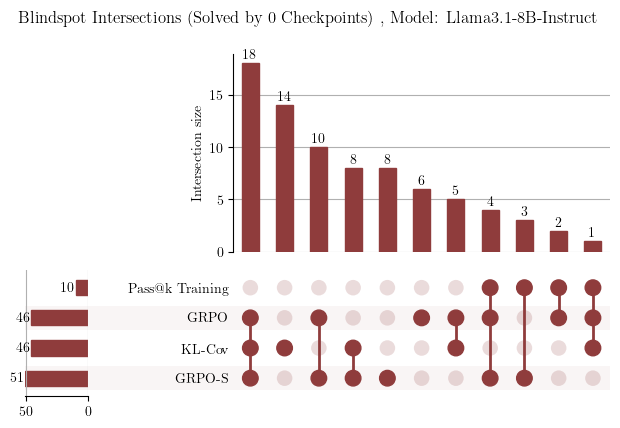

In [31]:
for m in models:
    subset = {k : v for k ,v in passk.items() if m in k}
    blindspots = preprocess_blindspots(subset, pretty_name='method')
    title = f", Model: {model_name_mapper[m]}"
    plot_upset_blindspots(blindspots, title_suffix=title)